In [1]:
import pandas as pd
import numpy as np

####  Importing dataset

In [2]:
bank_train_data = r'C:\Users\narma\Dropbox\datasets_edvancer_project\bank_problem\bank-full_train.csv'
bank_train = pd.read_csv(bank_train_data)

prediction_data = r'C:\Users\narma\Dropbox\datasets_edvancer_project\bank_problem\bank-full_test.csv'
predict_df = pd.read_csv(prediction_data)

In [3]:
bank_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,ID,y
0,45,blue-collar,married,secondary,no,2,no,no,cellular,26,aug,105,10,-1,0,unknown,22944,no
1,34,admin.,divorced,secondary,no,0,no,no,cellular,10,jul,268,1,-1,0,unknown,13870,no
2,40,technician,divorced,secondary,no,311,no,no,cellular,6,aug,738,2,-1,0,unknown,19301,yes
3,58,self-employed,married,tertiary,no,5810,no,no,cellular,12,mar,139,1,-1,0,unknown,31334,yes
4,59,blue-collar,married,secondary,no,169,yes,no,unknown,16,may,181,3,-1,0,unknown,3849,no


In [ ]:
bank_train.describe()


In [97]:
bank_train.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
ID           0
y            0
dtype: int64

In [5]:
bank_train.duplicated().value_counts()

False    31647
Name: count, dtype: int64

In [6]:
bank_train.shape

(31647, 18)

In [59]:
bank_train.nunique()
## can drop ID 

age             75
job             12
marital          3
education        4
default          2
balance       6245
housing          2
loan             2
contact          3
day             31
month           12
duration      1454
campaign        46
pdays          511
previous        38
poutcome         4
ID           31647
y                2
dtype: int64

In [8]:
import seaborn as sns

In [14]:
bank_train_copy = bank_train

In [15]:
bank_train_copy

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,ID,y
0,45,blue-collar,married,secondary,no,2,no,no,cellular,26,aug,105,10,-1,0,unknown,22944,no
1,34,admin.,divorced,secondary,no,0,no,no,cellular,10,jul,268,1,-1,0,unknown,13870,no
2,40,technician,divorced,secondary,no,311,no,no,cellular,6,aug,738,2,-1,0,unknown,19301,yes
3,58,self-employed,married,tertiary,no,5810,no,no,cellular,12,mar,139,1,-1,0,unknown,31334,yes
4,59,blue-collar,married,secondary,no,169,yes,no,unknown,16,may,181,3,-1,0,unknown,3849,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31642,37,technician,married,secondary,no,6963,yes,no,cellular,22,dec,158,2,-1,0,unknown,42547,no
31643,54,management,married,tertiary,no,8295,no,no,cellular,2,oct,849,2,119,1,success,41684,yes
31644,47,technician,married,tertiary,no,192,yes,no,unknown,26,may,596,1,-1,0,unknown,5827,no
31645,39,admin.,married,secondary,no,0,yes,no,cellular,17,jul,69,1,-1,0,unknown,15012,no


In [24]:
binarycol = ['default','housing','loan','y']

In [25]:
bank_train_copy[binarycol] = bank_train_copy[binarycol].replace( {'no': 0 , 'yes': 1} )

In [29]:
bank_train_copy.drop('ID', axis  =1)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,45,blue-collar,married,secondary,0,2,0,0,cellular,26,aug,105,10,-1,0,unknown,0
1,34,admin.,divorced,secondary,0,0,0,0,cellular,10,jul,268,1,-1,0,unknown,0
2,40,technician,divorced,secondary,0,311,0,0,cellular,6,aug,738,2,-1,0,unknown,1
3,58,self-employed,married,tertiary,0,5810,0,0,cellular,12,mar,139,1,-1,0,unknown,1
4,59,blue-collar,married,secondary,0,169,1,0,unknown,16,may,181,3,-1,0,unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31642,37,technician,married,secondary,0,6963,1,0,cellular,22,dec,158,2,-1,0,unknown,0
31643,54,management,married,tertiary,0,8295,0,0,cellular,2,oct,849,2,119,1,success,1
31644,47,technician,married,tertiary,0,192,1,0,unknown,26,may,596,1,-1,0,unknown,0
31645,39,admin.,married,secondary,0,0,1,0,cellular,17,jul,69,1,-1,0,unknown,0


### Exploratory Data Analyis

In [84]:
num_cols = bank_train_copy [['age','balance','day','duration','campaign','pdays','y']]

In [54]:
cat_cols = bank_train_copy[['job','marital','education','contact','month','poutcome']]

In [55]:
bina_cols = bank_train_copy[['default','housing','loan','previous']]

In [56]:
target_col = bank_train_copy['y']

In [57]:
bank_train_copy['y'].value_counts(normalize=True)

y
0    0.882453
1    0.117547
Name: proportion, dtype: float64

In [60]:
num_cols.corr()

,age,balance,day,duration,campaign,pdays
age,1.000000,0.104712,-0.006600,-0.007348,0.001913,-0.020160
balance,0.104712,1.000000,0.007062,0.016683,-0.016555,0.003595
day,-0.006600,0.007062,1.000000,-0.032348,0.164046,-0.094333
duration,-0.007348,0.016683,-0.032348,1.000000,-0.084246,-0.002576
campaign,0.001913,-0.016555,0.164046,-0.084246,1.000000,-0.088245
pdays,-0.020160,0.003595,-0.094333,-0.002576,-0.088245,1.000000


<Axes: xlabel='age', ylabel='Count'>

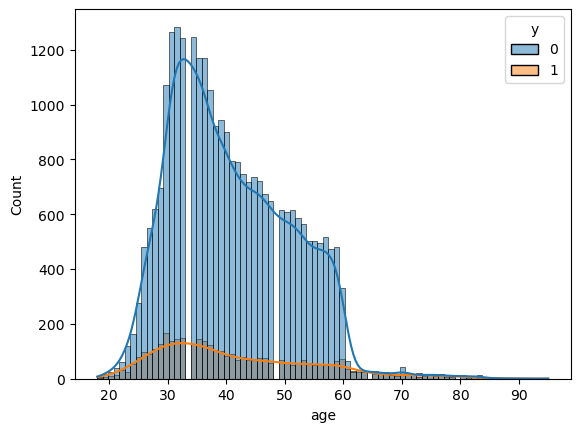

In [68]:
sns.histplot(x = 'age', data= bank_train , kde = True , hue = 'y' )

D:\Anaconda\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


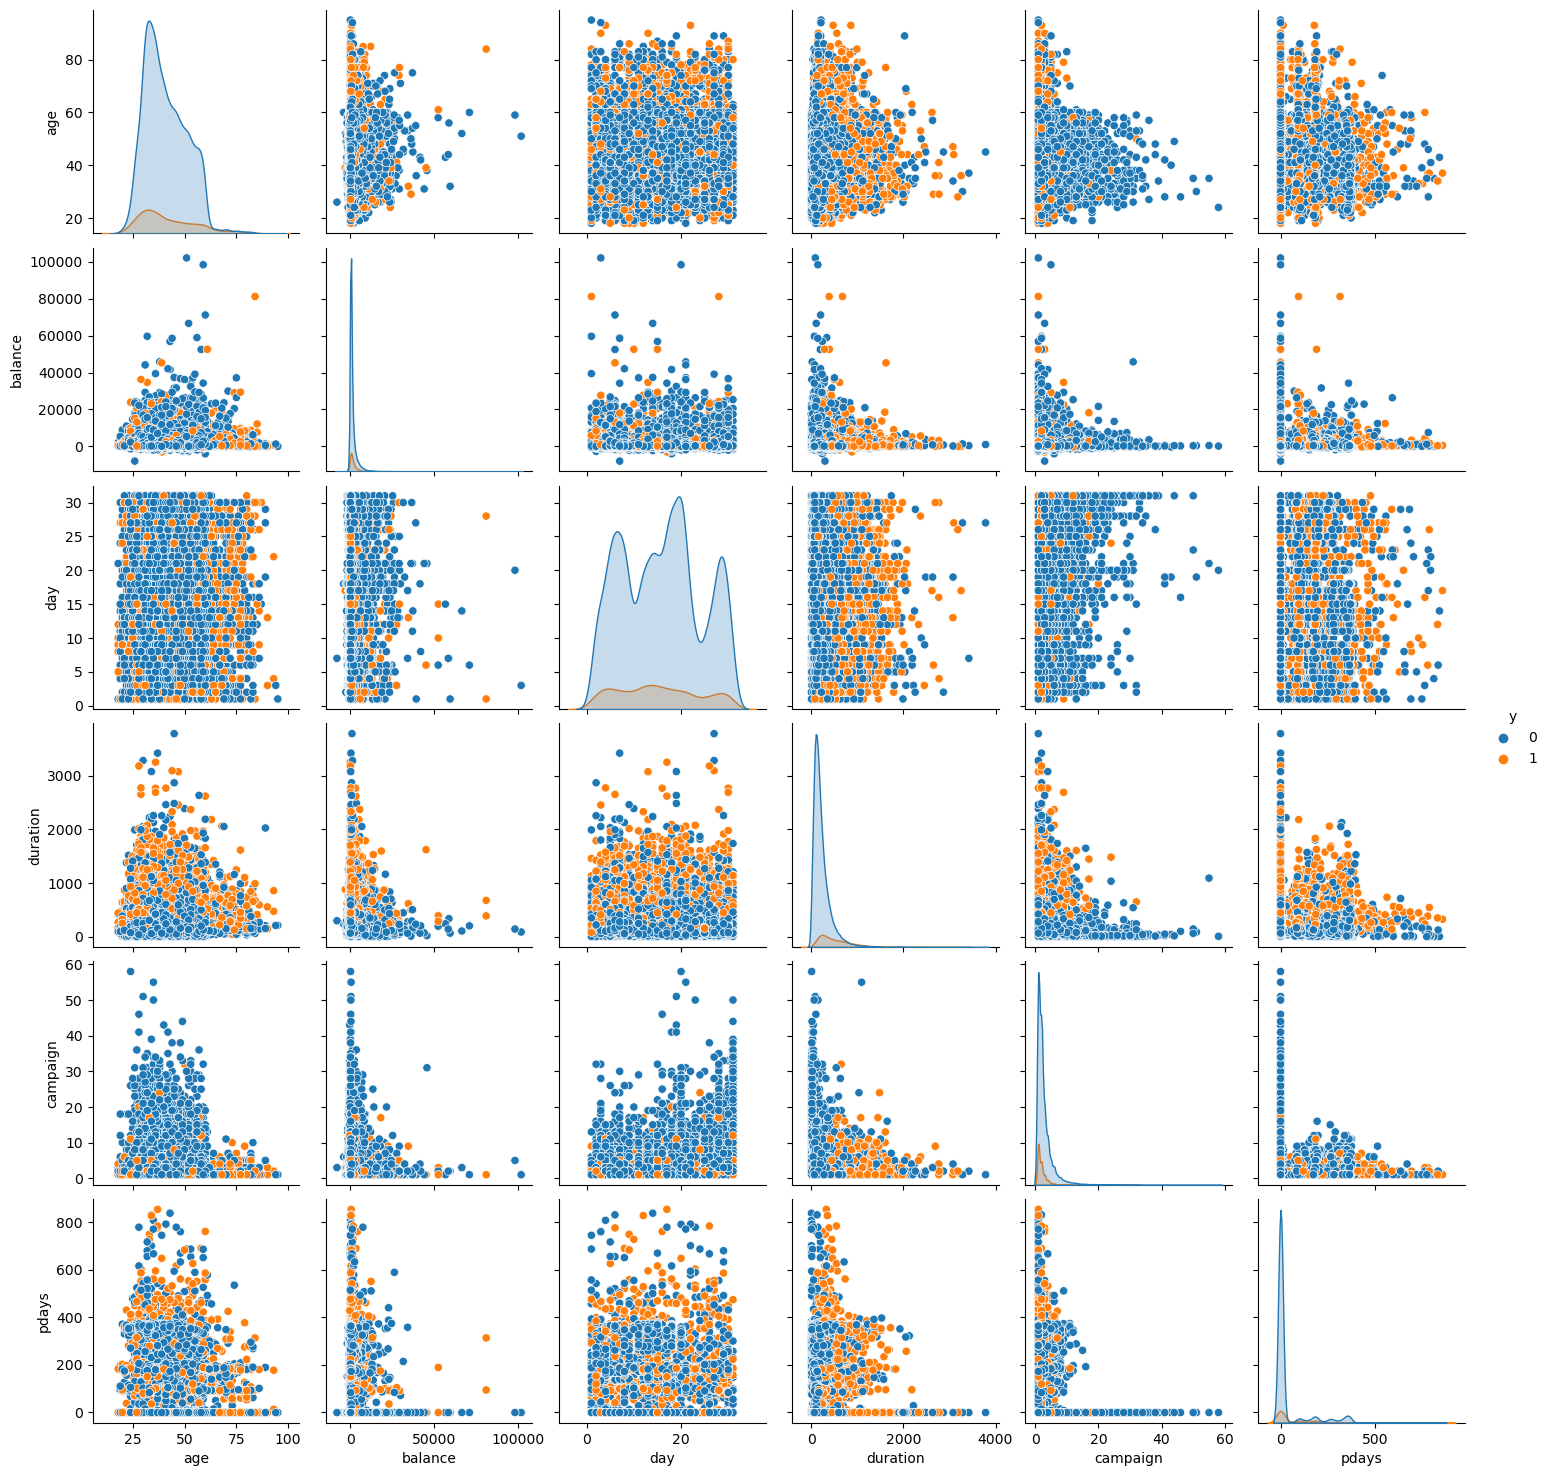

In [85]:
sns.pairplot(data = num_cols, hue= 'y')

<Axes: >

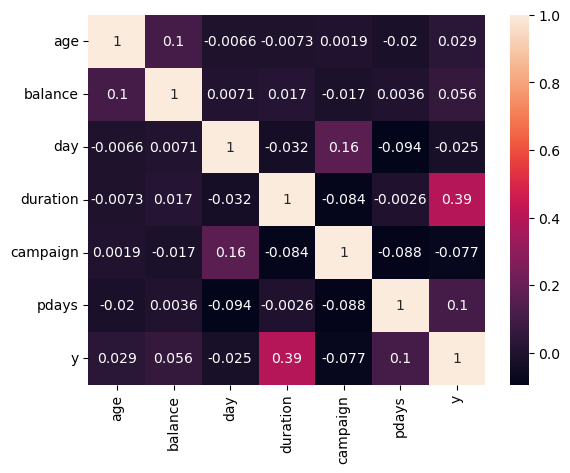

In [92]:
sns.heatmap( num_cols.corr(), annot= True)

<Axes: xlabel='marital', ylabel='Count'>

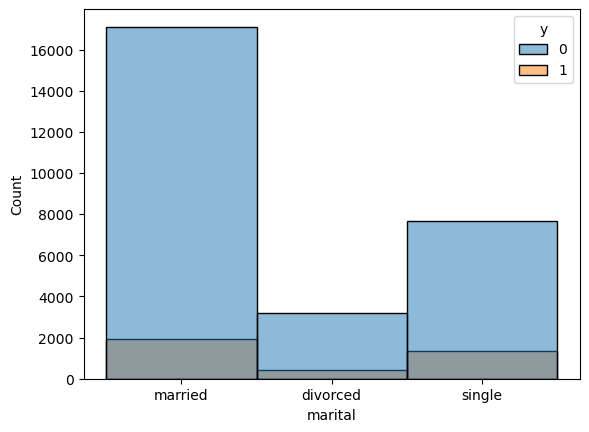

In [93]:
sns.histplot( x = 'marital', data = bank_train, hue = 'y')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'blue-collar'),
  Text(1, 0, 'admin.'),
  Text(2, 0, 'technician'),
  Text(3, 0, 'self-employed'),
  Text(4, 0, 'services'),
  Text(5, 0, 'entrepreneur'),
  Text(6, 0, 'management'),
  Text(7, 0, 'unemployed'),
  Text(8, 0, 'retired'),
  Text(9, 0, 'housemaid'),
  Text(10, 0, 'student'),
  Text(11, 0, 'unknown')])

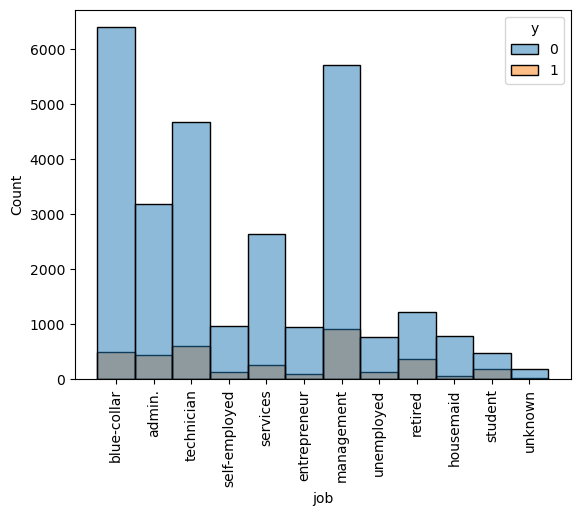

In [96]:
import matplotlib.pyplot as plt
sns.histplot( x = 'job', data = bank_train, hue = 'y')
plt.xticks(rotation = 90)

<Axes: xlabel='balance', ylabel='age'>

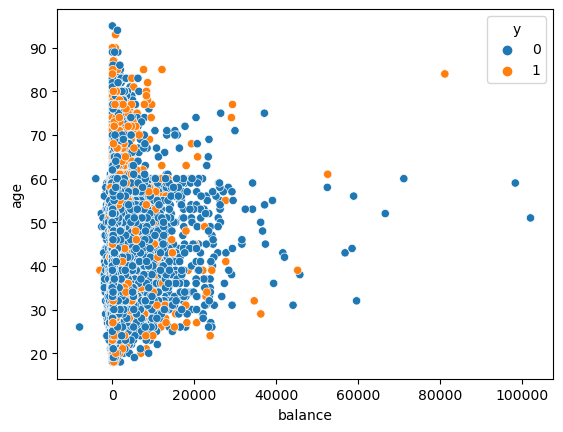

In [99]:
sns.scatterplot( data = bank_train , x = 'balance', y = 'age' , hue= 'y')

<Axes: xlabel='balance'>

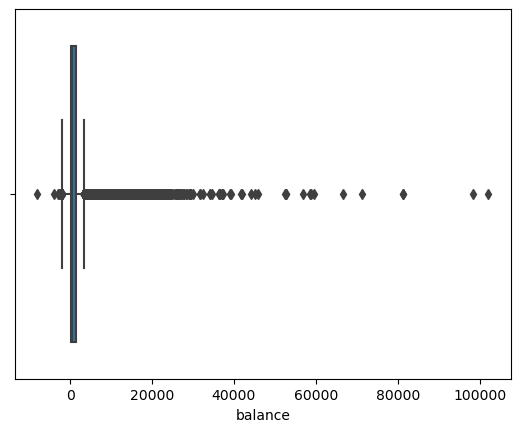

In [100]:
sns.boxplot( data = bank_train,  x = 'balance')